In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
from sklearn import datasets  
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics  
from sklearn.tree import plot_tree
from sklearn import tree
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

In [2]:
path = "/home/scruffy/Documents/Career Foundry/specialization/Data Sets"

In [28]:
df = pd.read_pickle(os.path.join(path, 'Dataset_scaled_answers_clean.pkl'))

In [29]:
#Create an 'X' matrix by dropping the unneeded columns.
X = df.drop(['DATE', 'MONTH','city','pleasant_weather'], axis=1)
y = df.pleasant_weather
print(X.shape)
print(y.shape)
X

(344250, 9)
(344250,)


,cloud_cover,global_radiation,humidity,precipitation,pressure,sunshine,temp_max,temp_mean,temp_min
0,0.862132,-1.030459,0.642743,-0.258065,0.107489,-1.008557,-0.266122,-0.388790,-0.638017
1,-1.638387,-0.455022,0.387073,-0.424729,0.205459,0.477063,-0.582091,-0.725164,-0.863394
2,-0.388128,-0.907151,-0.507772,-0.406211,0.042176,-0.631257,-0.876996,-0.881337,-0.797107
3,0.862132,-1.287350,0.642743,0.038226,-0.859148,-1.173626,-0.255590,-0.052416,0.236973
4,1.278885,-1.235972,0.514908,-0.276583,-0.016606,-1.173626,-0.202929,0.031677,0.183944
...,...,...,...,...,...,...,...,...,...
344245,0.028626,0.048484,0.514908,0.056745,-0.323579,0.429901,0.650188,0.380065,0.303260
344246,0.445379,-0.270061,1.409753,-0.035846,-0.101514,-0.725582,-0.013347,-0.064429,0.250231
344247,-0.388128,0.243722,0.578825,0.445628,0.649589,-0.065306,-1.129771,-0.965431,-0.651275
344248,0.028626,-0.218682,1.409753,-0.165474,0.002988,-1.079301,-0.087073,-0.004363,-0.081205


In [30]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [31]:
# creating a RF classifier
clf = RandomForestClassifier(n_estimators = 100, max_depth=10)  
  
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10)

In [32]:
# performing predictions on the test dataset
y_pred = clf.predict(X_test)

# Basic metrics
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
    
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# using metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test, y_pred))

Confusion Matrix:
[[54016     0]
 [    0 14834]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     54016
           1       1.00      1.00      1.00     14834

    accuracy                           1.00     68850
   macro avg       1.00      1.00      1.00     68850
weighted avg       1.00      1.00      1.00     68850

Model Accuracy:  1.0


In [51]:
important = pd.Series(clf.feature_importances_, index = X.columns) #.sort_values(ascending = False)
important

cloud_cover         0.030199
global_radiation    0.059759
humidity            0.014463
precipitation       0.317370
pressure            0.006428
sunshine            0.080594
temp_max            0.318556
temp_mean           0.137141
temp_min            0.035490
dtype: float64

Index(['cloud_cover', 'global_radiation', 'humidity', 'precipitation',
       'pressure', 'sunshine', 'temp_max', 'temp_mean', 'temp_min'],
      dtype='object')


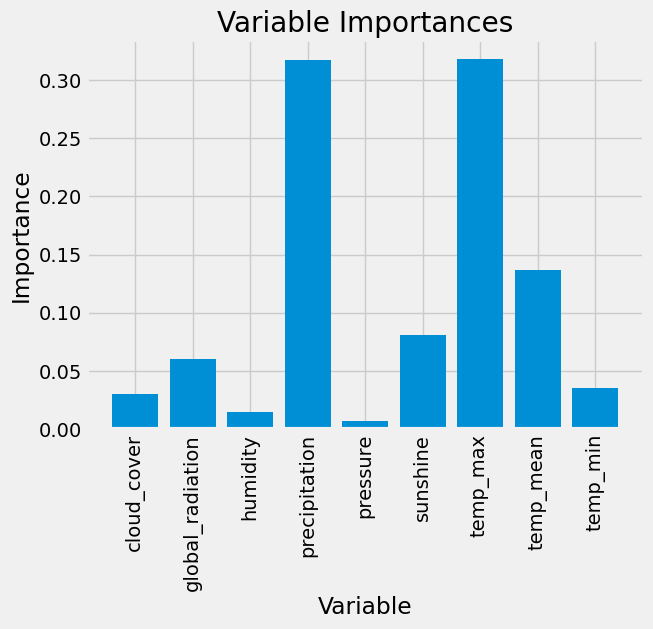

In [52]:
plt.style.use('fivethirtyeight')
# list of x locations for plotting
x_values = list(range(len(important)))
print(X.columns)

plt.bar(x_values, important, orientation = 'vertical')
plt.xticks(x_values, X.columns, rotation='vertical')
plt.ylabel('Importance'); plt.xlabel('Variable'); plt.title('Variable Importances')
plt.show()

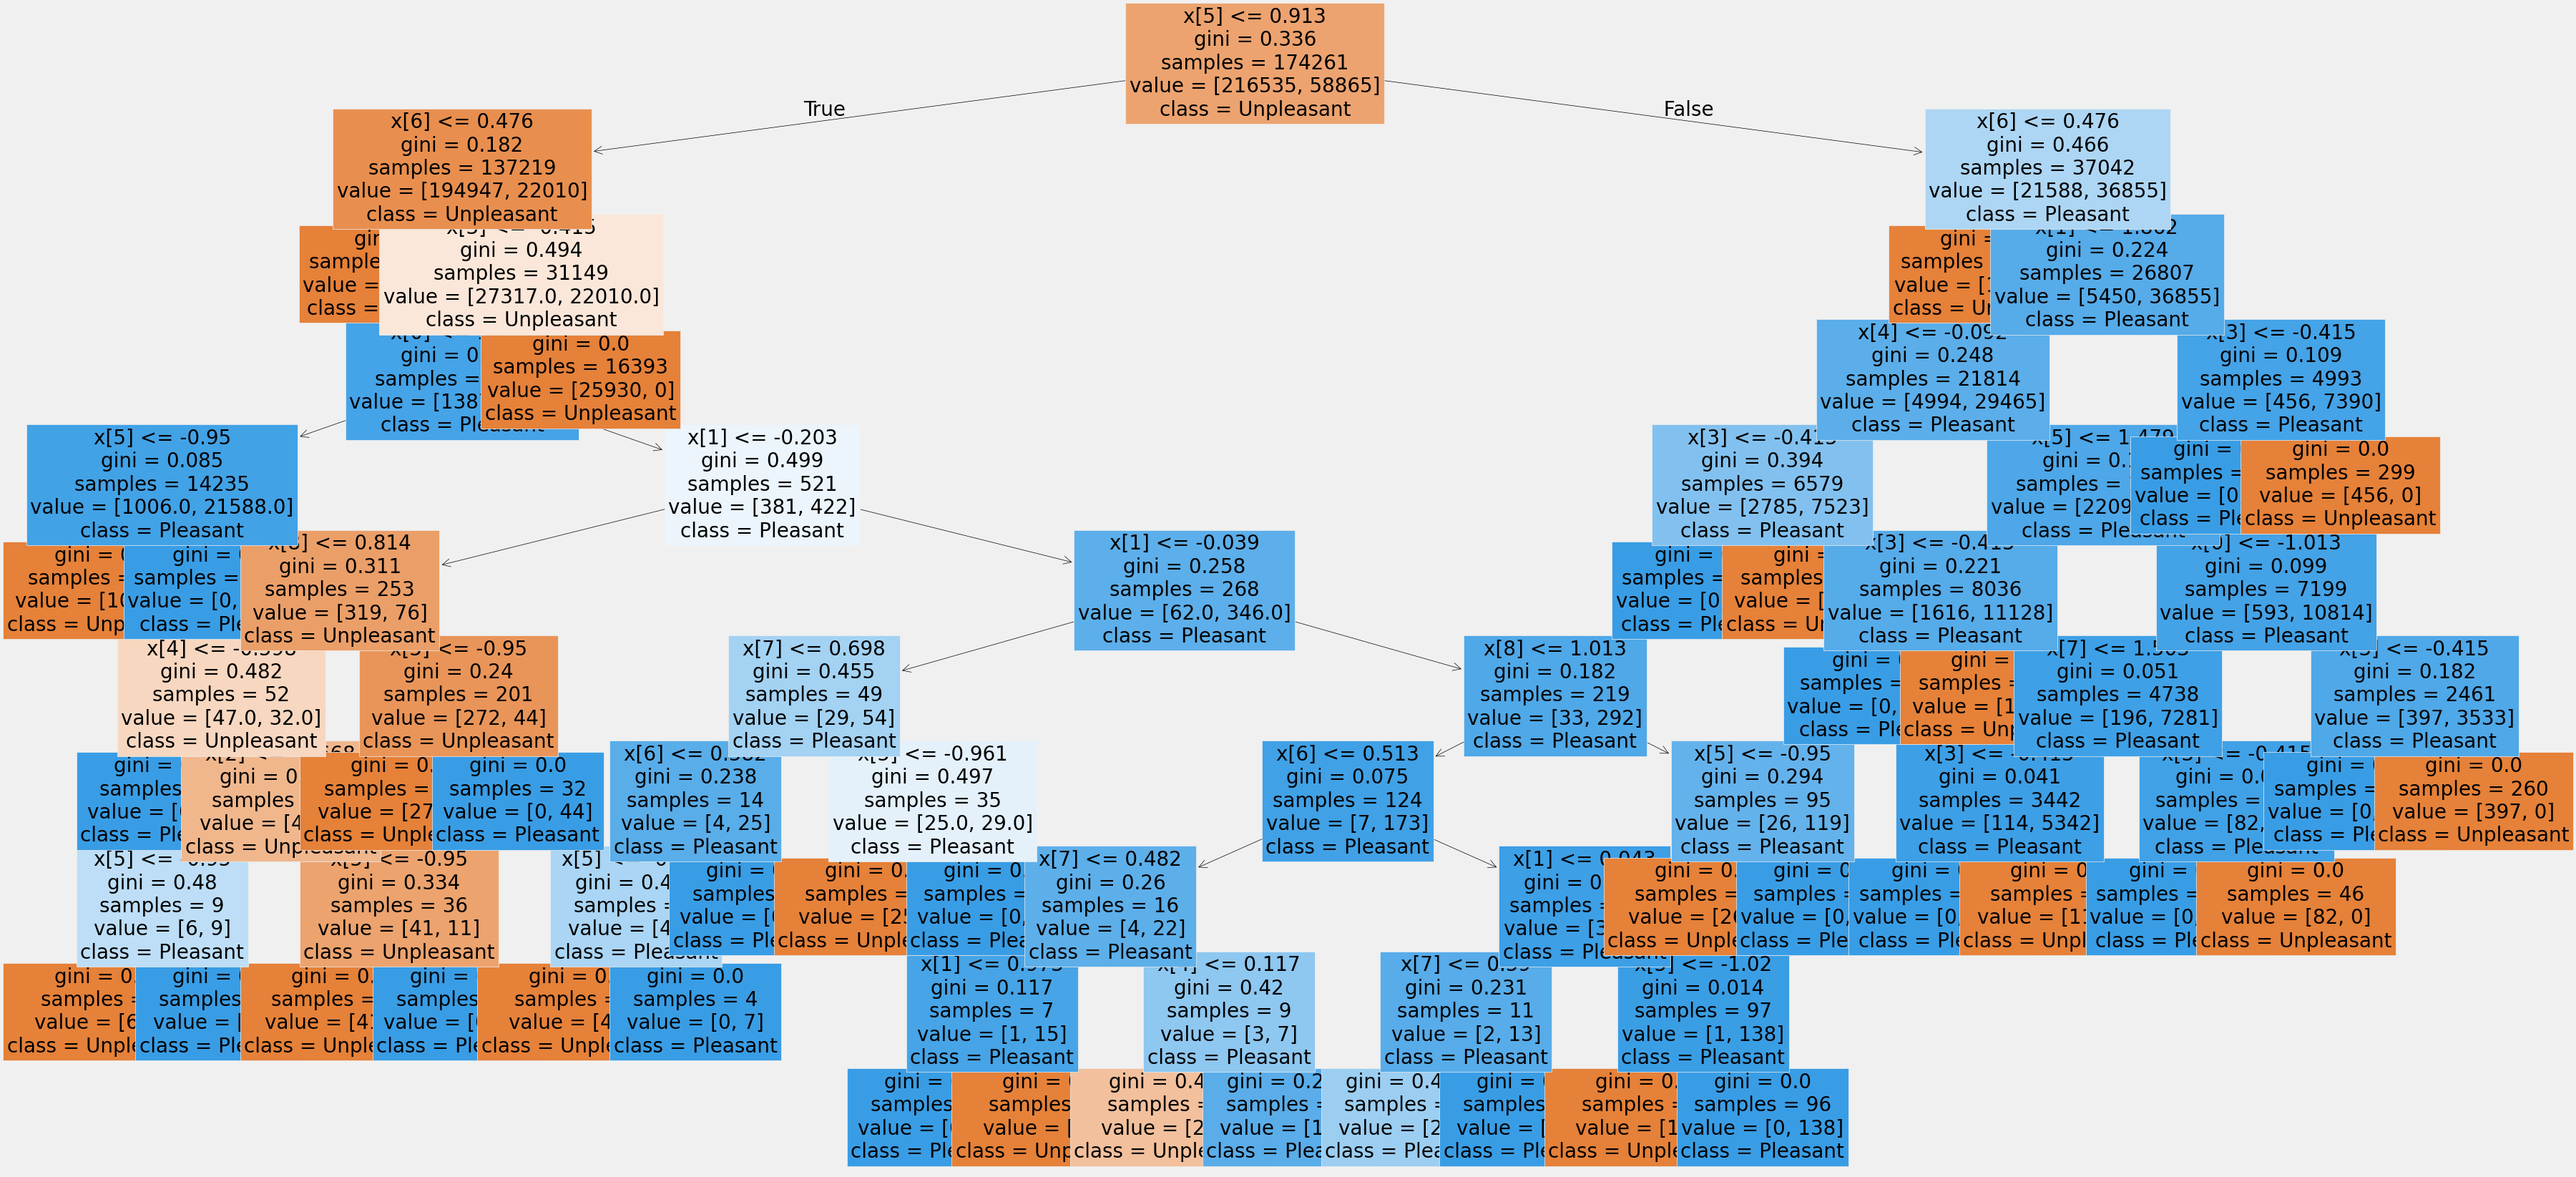

In [54]:
types = {0:'Unpleasant', 1:'Pleasant'}

fig = plt.figure(figsize=(40,20))
plot_tree(clf.estimators_[0], fontsize = 20, class_names=types, filled=True);

In [55]:
basel_df = df[df['city']=='BASEL']
heathrow_df = df[df['city']=='HEATHROW']
madrid_df = df[df['city']=='MADRID']

# Basel

In [56]:
X = basel_df.drop(['DATE', 'MONTH','city','pleasant_weather'], axis=1)
y = basel_df.pleasant_weather
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
basel_RF = RandomForestClassifier(n_estimators = 100, max_depth=10)

In [57]:
basel_RF.fit(X_train, y_train)

RandomForestClassifier(max_depth=10)

In [58]:
# performing predictions on the test dataset
y_pred = basel_RF.predict(X_test)
  
# using metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test, y_pred))

Model Accuracy:  1.0


In [59]:
important = pd.Series(basel_RF.feature_importances_, index = X.columns) #.sort_values(ascending = False)
important

cloud_cover         0.024005
global_radiation    0.111550
humidity            0.010193
precipitation       0.343809
pressure            0.008643
sunshine            0.126507
temp_max            0.258135
temp_mean           0.081959
temp_min            0.035198
dtype: float64

Index(['cloud_cover', 'global_radiation', 'humidity', 'precipitation',
       'pressure', 'sunshine', 'temp_max', 'temp_mean', 'temp_min'],
      dtype='object')


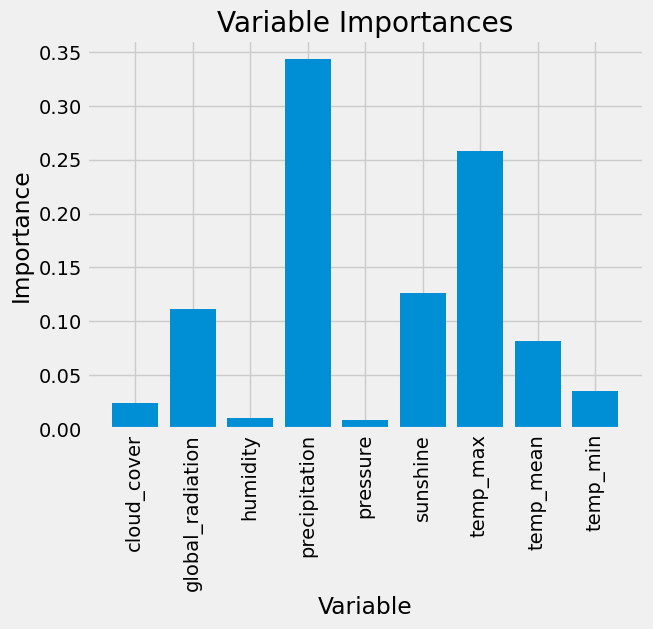

In [60]:
plt.style.use('fivethirtyeight')
# list of x locations for plotting
x_values = list(range(len(important)))
print(X.columns)

plt.bar(x_values, important, orientation = 'vertical')
plt.xticks(x_values, X.columns, rotation='vertical')
plt.ylabel('Importance'); plt.xlabel('Variable'); plt.title('Variable Importances')
plt.show()

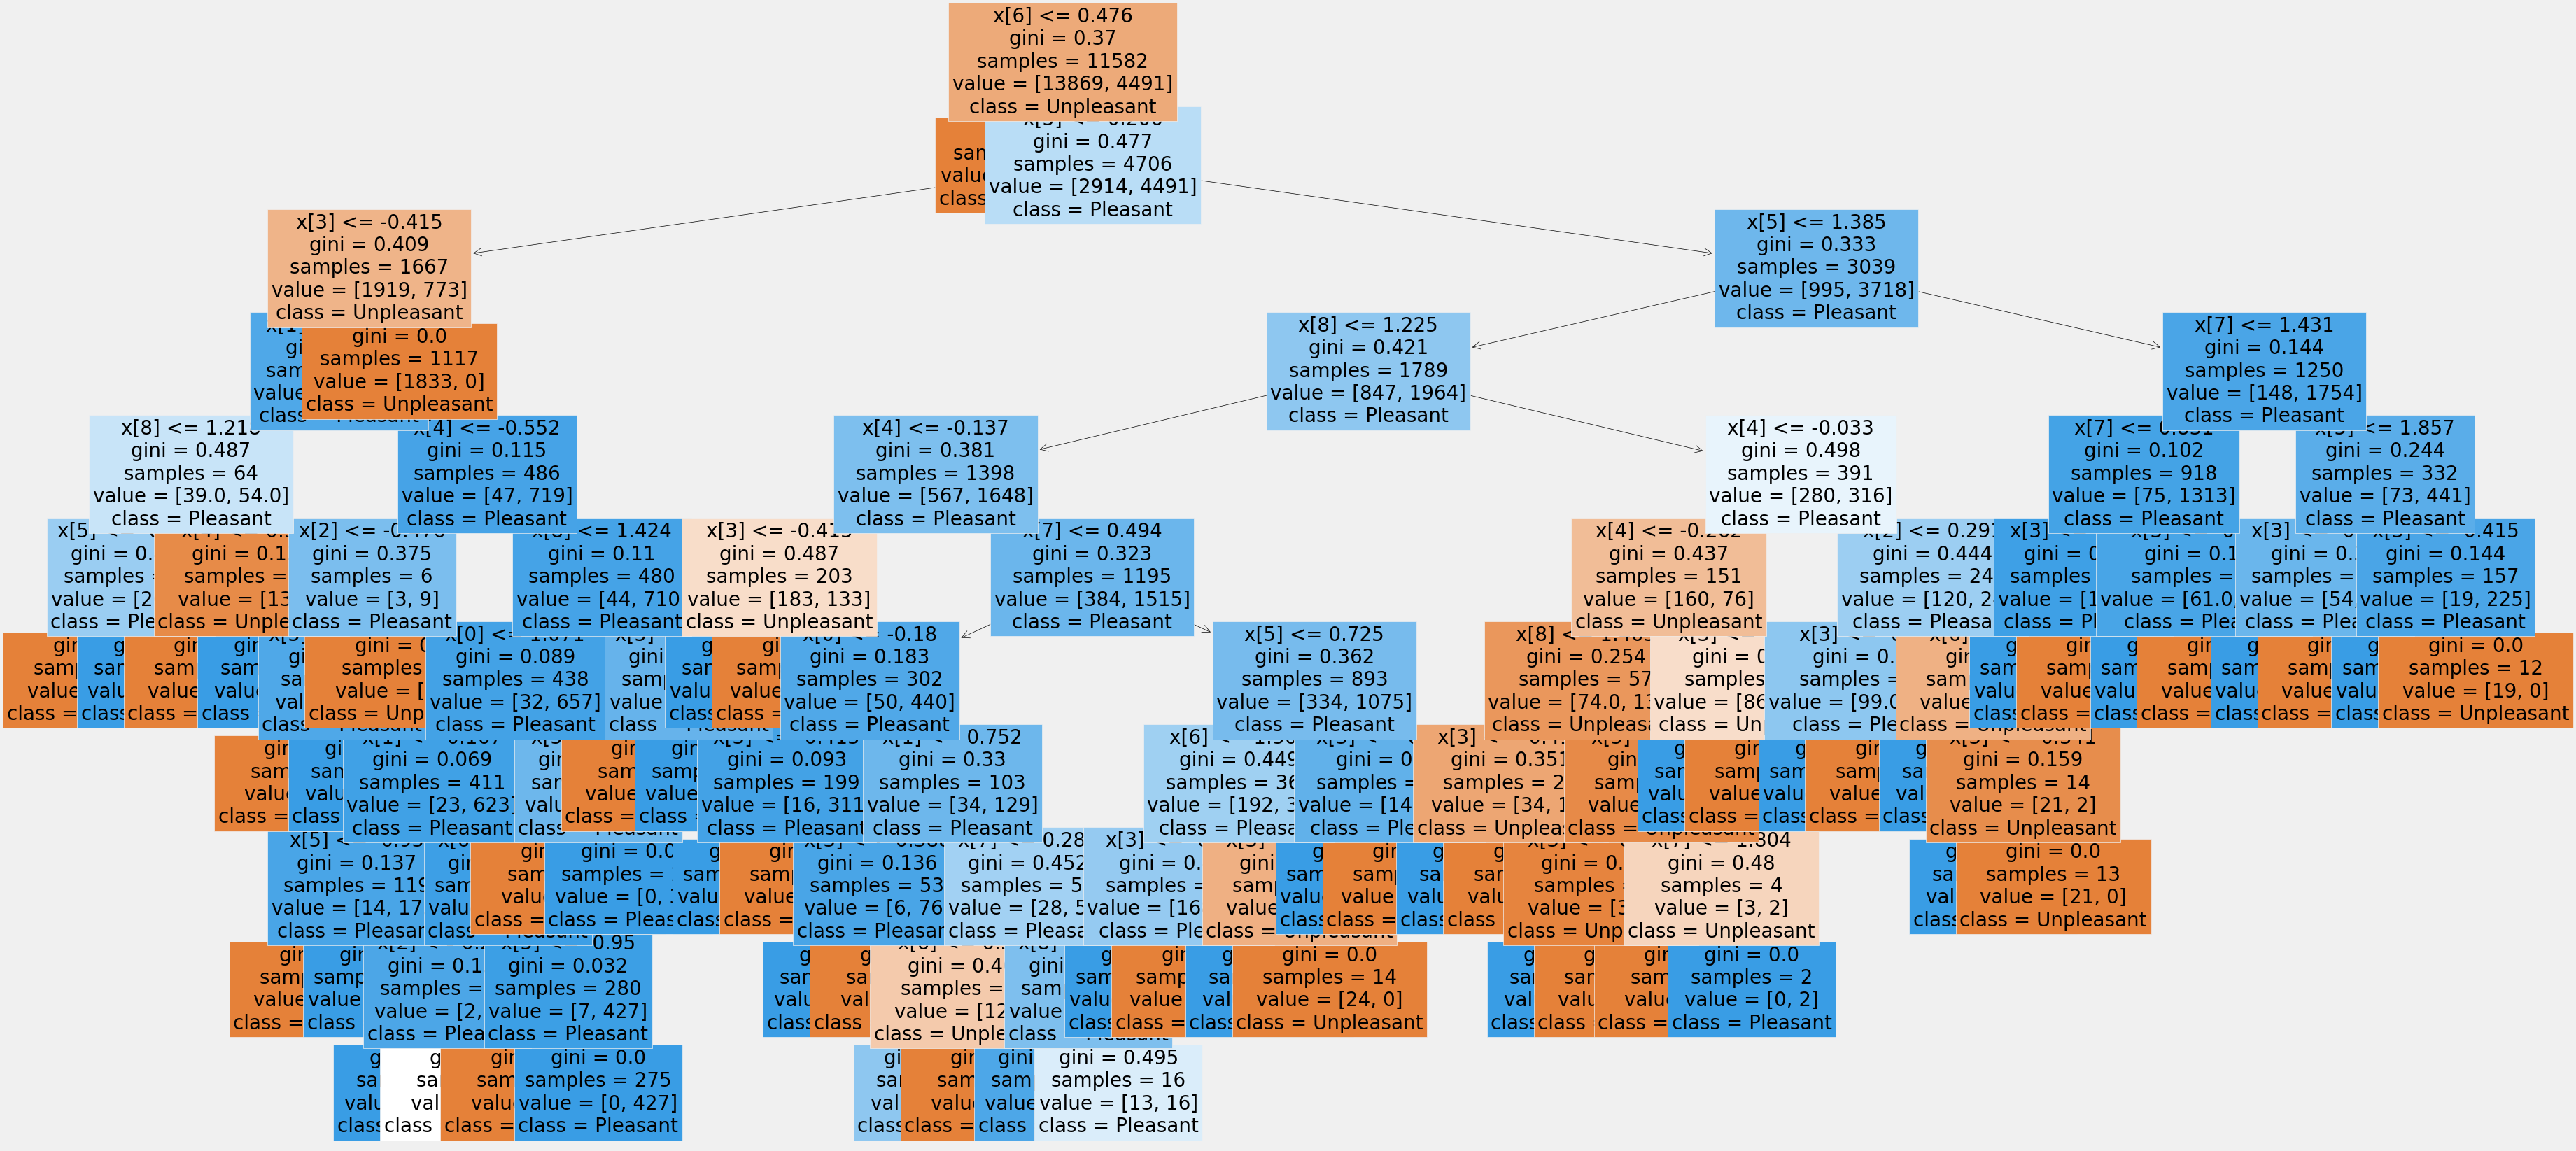

In [74]:
types = {0:'Unpleasant', 1:'Pleasant'}

fig = plt.figure(figsize=(40,20))
plot_tree(basel_RF.estimators_[0], fontsize = 20, class_names=types, filled=True);

# Heathrow

In [61]:
X = heathrow_df.drop(['DATE', 'MONTH','city','pleasant_weather'], axis=1)
y = heathrow_df.pleasant_weather
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
heathrow_df = RandomForestClassifier(n_estimators = 100, max_depth=10)
heathrow_df.fit(X_train, y_train)

RandomForestClassifier(max_depth=10)

In [62]:
# performing predictions on the test dataset
y_pred = heathrow_df.predict(X_test)
  
# using metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test, y_pred))

Model Accuracy:  1.0


In [63]:
important = pd.Series(heathrow_df.feature_importances_, index = X.columns) #.sort_values(ascending = False)
important

cloud_cover         0.011689
global_radiation    0.095599
humidity            0.024568
precipitation       0.307737
pressure            0.017601
sunshine            0.084602
temp_max            0.323668
temp_mean           0.121393
temp_min            0.013144
dtype: float64

Index(['cloud_cover', 'global_radiation', 'humidity', 'precipitation',
       'pressure', 'sunshine', 'temp_max', 'temp_mean', 'temp_min'],
      dtype='object')


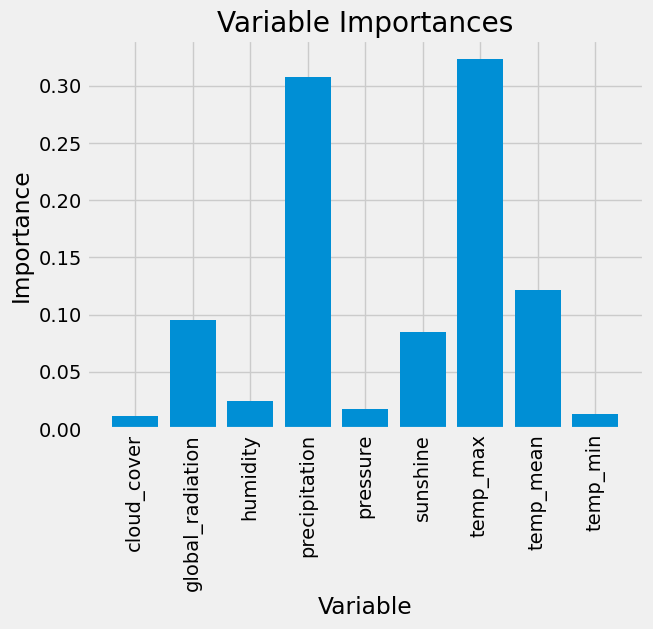

In [64]:
plt.style.use('fivethirtyeight')
# list of x locations for plotting
x_values = list(range(len(important)))
print(X.columns)

plt.bar(x_values, important, orientation = 'vertical')
plt.xticks(x_values, X.columns, rotation='vertical')
plt.ylabel('Importance'); plt.xlabel('Variable'); plt.title('Variable Importances')
plt.show()

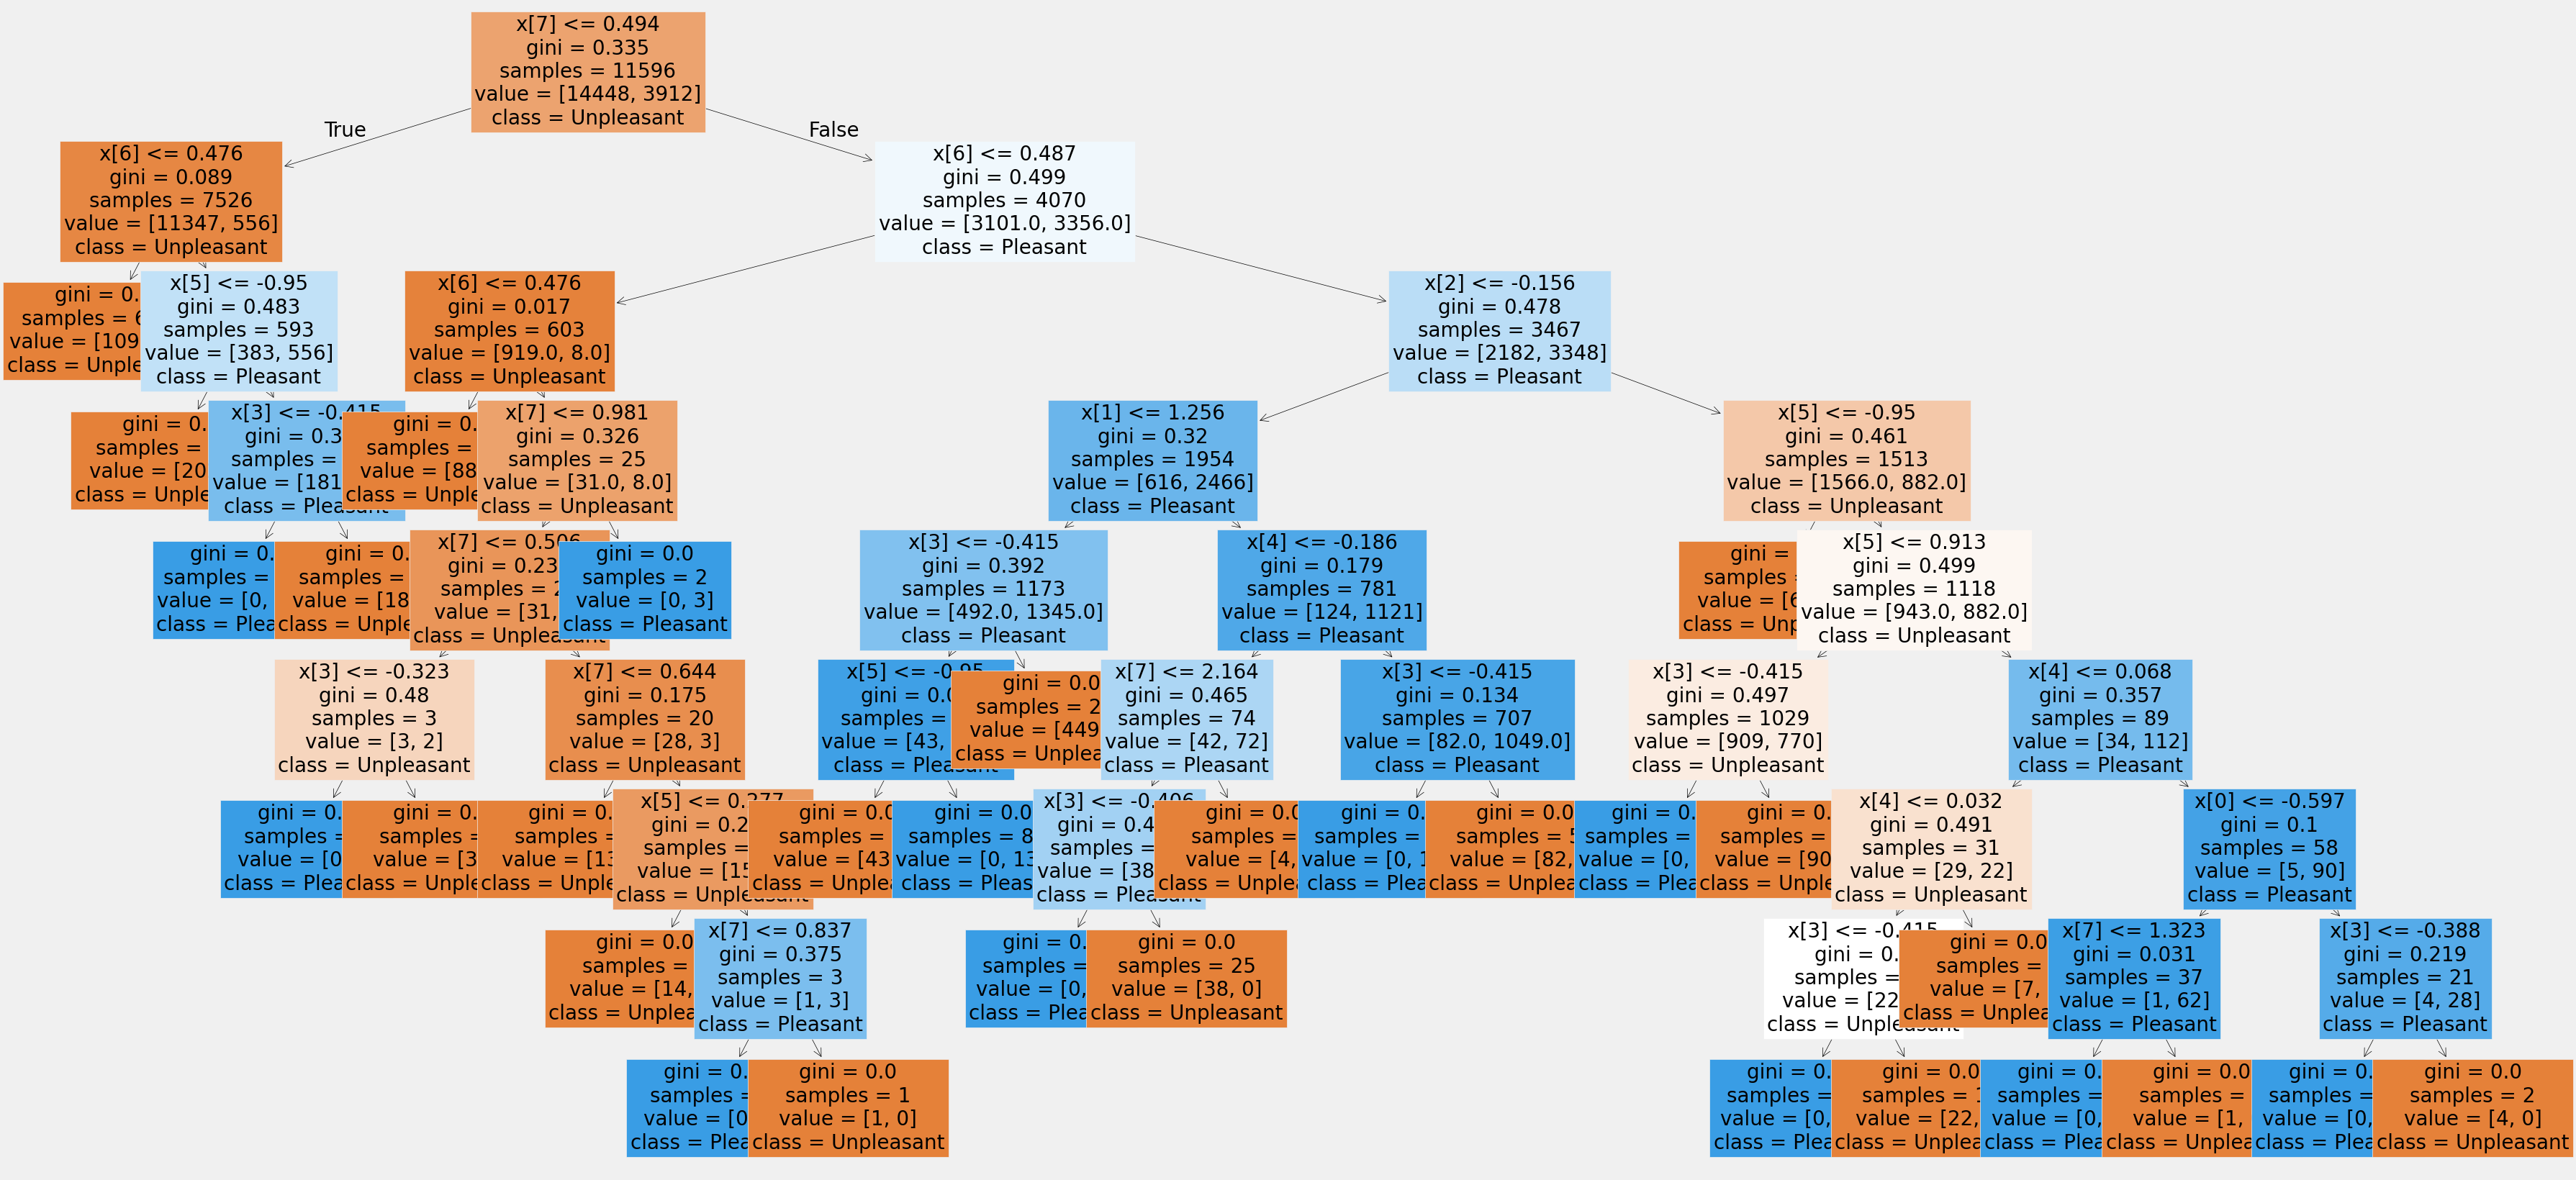

In [76]:
types = {0:'Unpleasant', 1:'Pleasant'}

fig = plt.figure(figsize=(40,20))
plot_tree(heathrow_df.estimators_[0], fontsize = 20, class_names=types, filled=True);

# Madrid

In [70]:
X = madrid_df.drop(['DATE', 'MONTH','city','pleasant_weather'], axis=1)
y = madrid_df.pleasant_weather
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
madrid_RF = RandomForestClassifier(n_estimators = 100, max_depth=10)
madrid_RF.fit(X_train, y_train)

RandomForestClassifier(max_depth=10)

In [71]:
# performing predictions on the test dataset
y_pred = madrid_RF.fit(X_train, y_train).predict(X_test)
  
# using metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test, y_pred))

Model Accuracy:  1.0


In [72]:
important = pd.Series(madrid_RF.feature_importances_, index = X.columns) #.sort_values(ascending = False)
important

cloud_cover         0.012964
global_radiation    0.111822
humidity            0.022044
precipitation       0.208908
pressure            0.003269
sunshine            0.094335
temp_max            0.280936
temp_mean           0.187919
temp_min            0.077803
dtype: float64

Index(['cloud_cover', 'global_radiation', 'humidity', 'precipitation',
       'pressure', 'sunshine', 'temp_max', 'temp_mean', 'temp_min'],
      dtype='object')


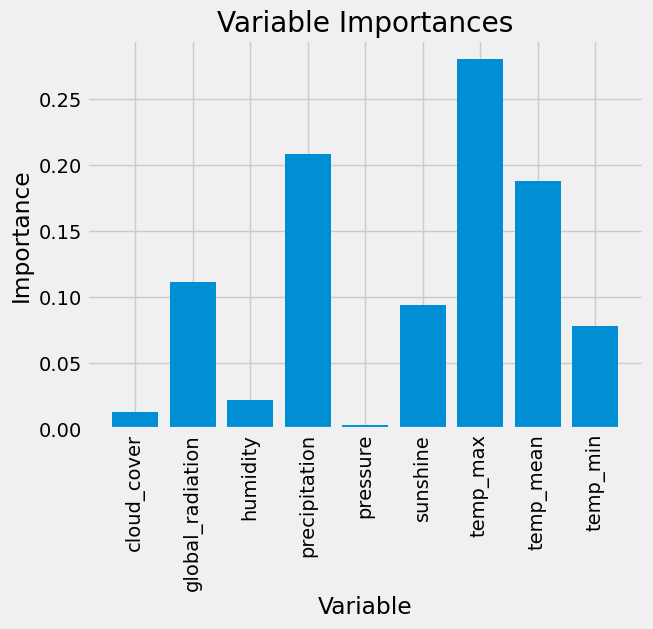

In [73]:
plt.style.use('fivethirtyeight')
# list of x locations for plotting
x_values = list(range(len(important)))
print(X.columns)

plt.bar(x_values, important, orientation = 'vertical')
plt.xticks(x_values, X.columns, rotation='vertical')
plt.ylabel('Importance'); plt.xlabel('Variable'); plt.title('Variable Importances')
plt.show()

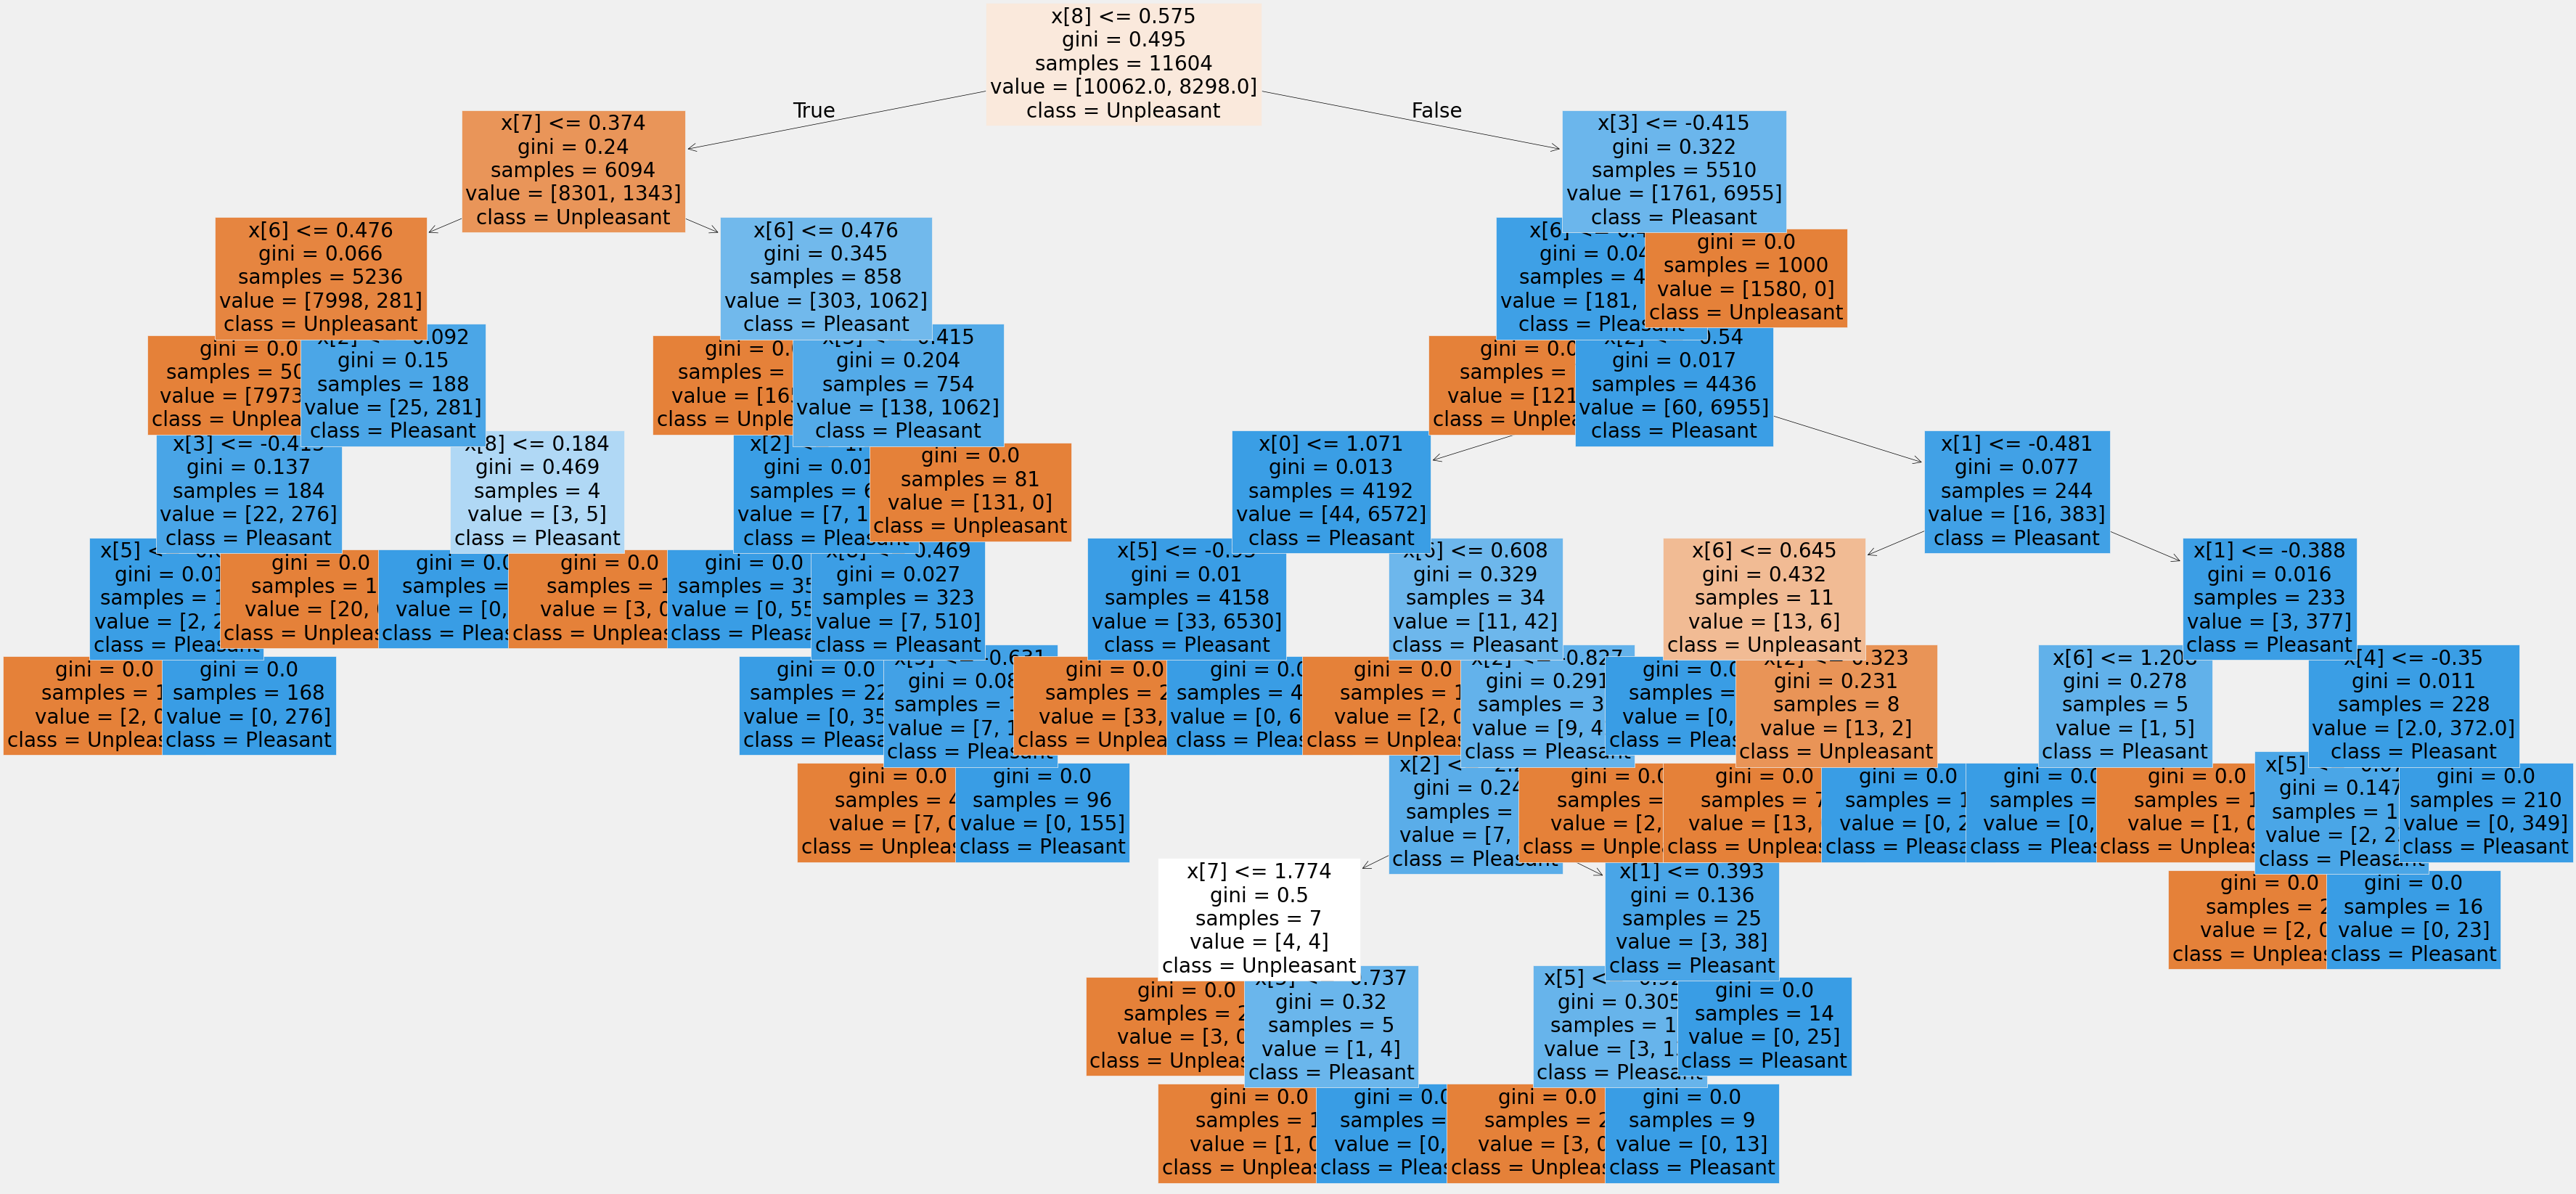

In [77]:
types = {0:'Unpleasant', 1:'Pleasant'}

fig = plt.figure(figsize=(40,20))
plot_tree(madrid_RF.estimators_[0], fontsize = 20, class_names=types, filled=True);

# Prediction

In [18]:
df = df.sort_values(['city','DATE'], ascending=[True,False])

In [19]:
df

,DATE,MONTH,city,cloud_cover,global_radiation,humidity,precipitation,pressure,sunshine,temp_max,temp_mean,temp_min,pleasant_weather
344235,2022-10-31,10,BASEL,0.028626,0.017657,0.578825,-0.017328,0.192396,-0.419025,0.608058,0.452145,0.568409,0
344220,2022-10-30,10,BASEL,0.028626,0.017657,0.323155,-0.017328,0.316491,0.194088,0.808172,0.680398,0.793786,0
344205,2022-10-29,10,BASEL,-0.388128,0.017657,0.067485,-0.017328,0.414461,0.264832,0.945092,0.836572,0.992647,0
344190,2022-10-28,10,BASEL,0.445379,0.017657,0.131403,-0.017328,0.525494,0.099763,0.892430,0.836572,1.151736,0
344175,2022-10-27,10,BASEL,-1.638387,0.017657,0.259238,-0.017328,0.551619,0.642132,0.839769,0.740465,0.767271,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,1960-01-05,1,VALENTIA,-0.804881,-0.886600,0.323155,-0.424729,1.074125,0.170507,-0.529430,-0.484897,-0.346354,0
59,1960-01-04,1,VALENTIA,0.862132,-1.225696,0.706660,1.390058,0.133614,-1.173626,-0.297719,-0.280670,0.223716,0
44,1960-01-03,1,VALENTIA,0.862132,-1.184594,1.026248,-0.276583,-0.441143,-1.150045,-0.055476,0.091744,0.329775,0
29,1960-01-02,1,VALENTIA,0.862132,-1.102388,1.026248,1.130802,-1.022431,-1.008557,-0.139735,-0.100469,-0.001661,0


In [20]:
df['pleasant_weather']=df['pleasant_weather'].shift(periods=1, fill_value=0)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 344250 entries, 344235 to 14
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DATE              344250 non-null  datetime64[ns]
 1   MONTH             344250 non-null  int64         
 2   city              344250 non-null  object        
 3   cloud_cover       344250 non-null  float64       
 4   global_radiation  344250 non-null  float64       
 5   humidity          344250 non-null  float64       
 6   precipitation     344250 non-null  float64       
 7   pressure          344250 non-null  float64       
 8   sunshine          344250 non-null  float64       
 9   temp_max          344250 non-null  float64       
 10  temp_mean         344250 non-null  float64       
 11  temp_min          344250 non-null  float64       
 12  pleasant_weather  344250 non-null  int64         
dtypes: datetime64[ns](1), float64(9), int64(2), object(1)
memory us

In [23]:
#Create an 'X' matrix by dropping the unneeded columns.
X = df.drop(['DATE', 'MONTH','city','pleasant_weather'], axis=1)
y = df.pleasant_weather
print(X.shape)
print(y.shape)
X

(344250, 9)
(344250,)


,cloud_cover,global_radiation,humidity,precipitation,pressure,sunshine,temp_max,temp_mean,temp_min
344235,0.028626,0.017657,0.578825,-0.017328,0.192396,-0.419025,0.608058,0.452145,0.568409
344220,0.028626,0.017657,0.323155,-0.017328,0.316491,0.194088,0.808172,0.680398,0.793786
344205,-0.388128,0.017657,0.067485,-0.017328,0.414461,0.264832,0.945092,0.836572,0.992647
344190,0.445379,0.017657,0.131403,-0.017328,0.525494,0.099763,0.892430,0.836572,1.151736
344175,-1.638387,0.017657,0.259238,-0.017328,0.551619,0.642132,0.839769,0.740465,0.767271
...,...,...,...,...,...,...,...,...,...
74,-0.804881,-0.886600,0.323155,-0.424729,1.074125,0.170507,-0.529430,-0.484897,-0.346354
59,0.862132,-1.225696,0.706660,1.390058,0.133614,-1.173626,-0.297719,-0.280670,0.223716
44,0.862132,-1.184594,1.026248,-0.276583,-0.441143,-1.150045,-0.055476,0.091744,0.329775
29,0.862132,-1.102388,1.026248,1.130802,-1.022431,-1.008557,-0.139735,-0.100469,-0.001661


In [24]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [25]:
# creating a RF classifier
clf = RandomForestClassifier(n_estimators = 100, max_depth=10)  
  
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10)

In [27]:
# performing predictions on the test dataset
y_pred = clf.predict(X_test)

# Basic metrics
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
    
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# using metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test, y_pred))

Confusion Matrix:
[[50025  3985]
 [ 4768 10072]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92     54010
           1       0.72      0.68      0.70     14840

    accuracy                           0.87     68850
   macro avg       0.81      0.80      0.81     68850
weighted avg       0.87      0.87      0.87     68850

Model Accuracy:  0.8728685548293391


In [43]:
important = pd.Series(clf.feature_importances_, index = X.columns) #.sort_values(ascending = False)
important

cloud_cover         0.030330
global_radiation    0.068360
humidity            0.024205
precipitation       0.094161
pressure            0.048526
sunshine            0.047450
temp_max            0.326511
temp_mean           0.264113
temp_min            0.096344
dtype: float64

Index(['cloud_cover', 'global_radiation', 'humidity', 'precipitation',
       'pressure', 'sunshine', 'temp_max', 'temp_mean', 'temp_min'],
      dtype='object')


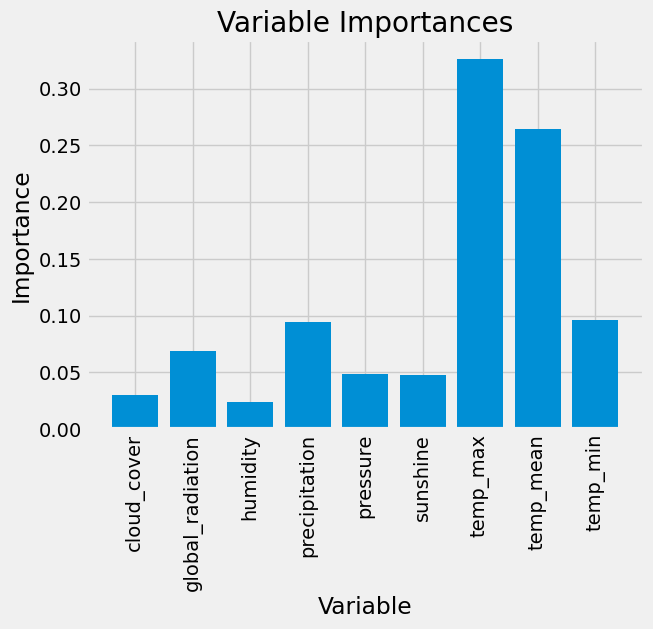

In [44]:
plt.style.use('fivethirtyeight')
# list of x locations for plotting
x_values = list(range(len(important)))
print(X.columns)

plt.bar(x_values, important, orientation = 'vertical')
plt.xticks(x_values, X.columns, rotation='vertical')
plt.ylabel('Importance'); plt.xlabel('Variable'); plt.title('Variable Importances')
plt.show()

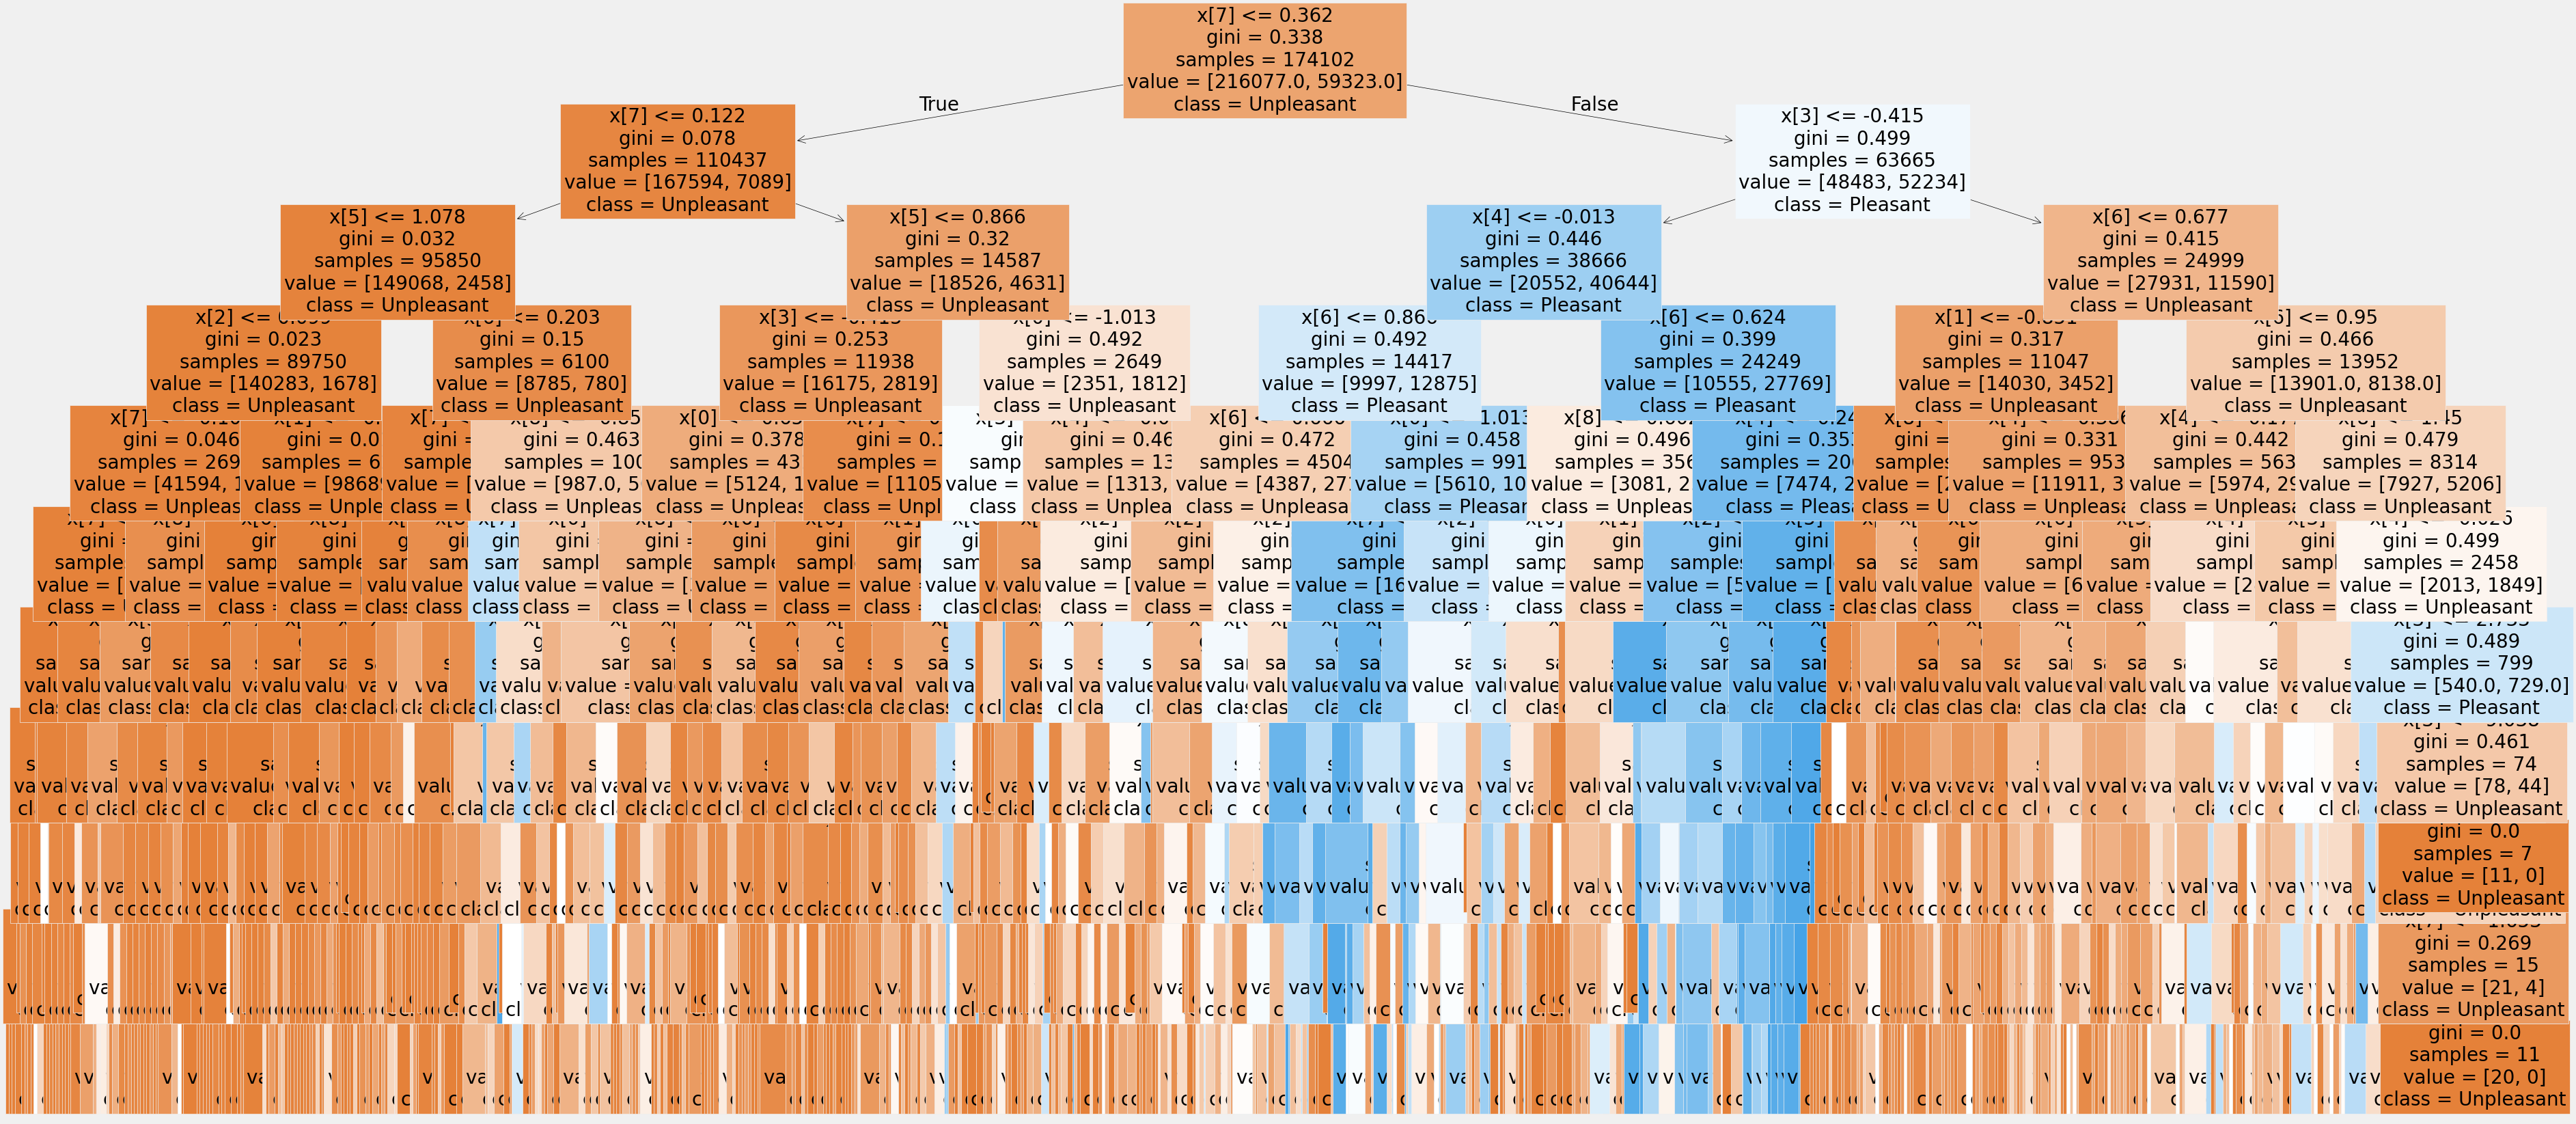

In [45]:
types = {0:'Unpleasant', 1:'Pleasant'}

fig = plt.figure(figsize=(40,20))
plot_tree(clf.estimators_[5], fontsize = 20, class_names=types, filled=True);